In [47]:
from scipy.io import loadmat
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Demo 3:
### 3d Arrays and Mapping

Last week, we used **Pandas** to handle tabular data (like .csv files of excel spreadhseets). However, it struggles with multidimensional data. Fear not! **Xarray** is a great alternative for handling multidimensional data. 

Today's dataset is **3D**, consisting of:
1. Time (311 steps)
2. Latitude (121 points)
3. Longitude (161 points)

### Why Xarray? (Xarray vs. Pandas)

For 1D or 2D "spreadsheet-style" data, **Pandas** is the industry standard. However, for 3D Earth Science data (like Sea Level over Time, Lat, and Lon), **Xarray** is significantly more powerful.

| Feature | Pandas | Xarray |
| :--- | :--- | :--- |
| **Data Model** | Tabular (Rows & Columns) | Multidimensional (N-Dimensional) |
| **Best For** | Financial records, CSVs, simple lists. | Gridded data (Satellite, Climate models). |
| **Dimensions** | 1D (Series) or 2D (DataFrame). | ND (DataArray or Dataset). |
| **Handling 3D** | Requires "Flattening" or complex Multi-Indexing. | Native 3D support (Time, Lat, Lon). |
| **Alignment** | Aligns by Row/Column index. | Aligns by physical coordinates (Degrees/Dates). |
| **Selection** | `df.iloc[0:10]` (Position-based) | `ds.sel(lat=-20.5)` (Value-based) |

In [25]:
# load data
mat = loadmat('/Users/isidorarojas/Desktop/DIRECTORY/2026/SIO175_DataAnalysis/Module_2/data/Module2_Python_Ready.mat', squeeze_me=True)
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'alt_time_str', 'lat', 'lon', 'oni', 'sl'])

### Building your first Xarray Dataset

In [45]:
# extract raw data from MATLAB dictionary 
sea_level = mat['sl']
lat  = mat['lat']
lon = mat['lon']
oni = mat['oni']

# convert MATLAB time strings into datetime
time = pd.to_datetime(mat['alt_time_str'])

# assemble the xarray dataset
# this is where we label the dimensions of our 3D array
ds = xr.Dataset(
    data_vars={
        # Format: "Variable_Name": (("Dim1", "Dim2", "Dim3"), actual_data)
        "sl": (("time", "lat", "lon"), sea_level),
        "oni": (("time"), oni),
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon,
    },
    attrs={
        "description": "Sea level and ONI data for SIO175",
        "units": "meters"
    }
)
# integer selection (.isel)
print(ds.sl.isel(time=slice(0,5), lat=0, lon=0)) # integer selection


<xarray.DataArray 'sl' (time: 5)> Size: 40B
array([-0.08552581,  0.00952857, -0.04702903, -0.04775333,  0.08120968])
Coordinates:
  * time     (time) datetime64[ns] 40B 1993-01-16 1993-02-14 ... 1993-05-16
    lat      float64 8B -59.88
    lon      float64 8B 130.1


In [46]:
# label selection (.sel)
print(ds.sl.sel(time='2004-01-01', method='nearest'))

<xarray.DataArray 'sl' (lat: 121, lon: 161)> Size: 156kB
array([[-0.00492903,  0.01586774,  0.00398387, ...,  0.08614194,
         0.04976129,  0.00337742],
       [ 0.08482258, -0.01006452, -0.06722581, ...,  0.00870323,
        -0.05081935, -0.13887097],
       [ 0.04368065, -0.01154194, -0.03753226, ..., -0.02653226,
        -0.1133129 , -0.11458065],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])
Coordinates:
    time     datetime64[ns] 8B 2004-01-16
  * lat      (lat) float64 968B -59.88 -58.88 -57.88 ... 58.12 59.12 60.12
  * lon      (lon) float64 1kB 130.1 131.1 132.1 133.1 ... 288.1 289.1 290.1


**Key XArray Concepts:**

- `data_vars`:These are yor actual measurements (Sea level, temperature, ONI, etc. )
- `coords`: These are the "axes" of your data. because we named our dimension "time", Xarray knows that `ds.sea_level` and `ds.oni` share the same time axis. 
- `attrs`: short for attributes. This is wehre you can store metadata like "readme" info containg sensr info, data collector etc. etc. 

### Plot: Time series of Sea Level at 20° lat and 180° lon

use method='nearest' and .sel() for the coordinate values

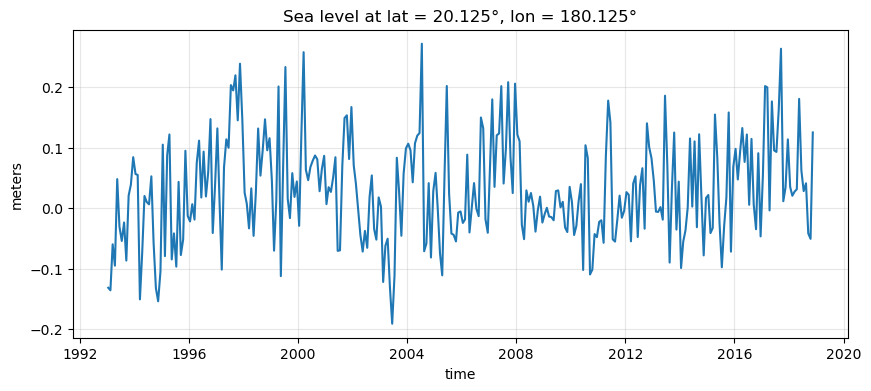

In [50]:
time_plot = ds.sl.sel(lat=20, lon=180, method='nearest')

plt.figure(figsize=(10,4))
time_plot.plot()

# use metadata for labelling
# (Xarray pulls title and labels automatically, but you can override)
plt.title(f"Sea level at lat = {time_plot.lat.values}°, lon = {time_plot.lon.values}°")
plt.ylabel("meters")
plt.grid(True, alpha=0.3)
plt.show()

### Plot: Spatial map of sealevel

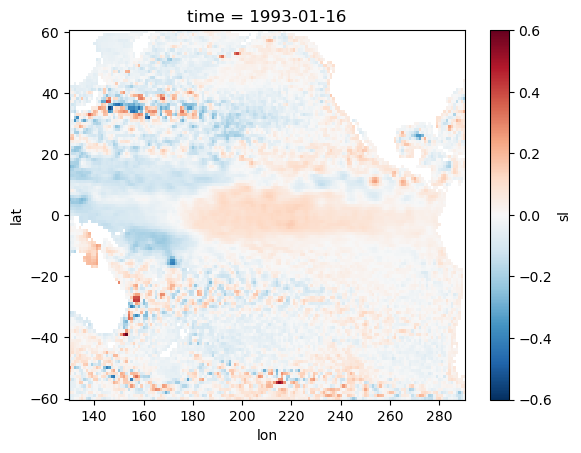

In [ ]:
# easy plotting with xarray
# plot the first time step:
ds.sl.isel(time=0).plot()

adding features to an xarray plot:

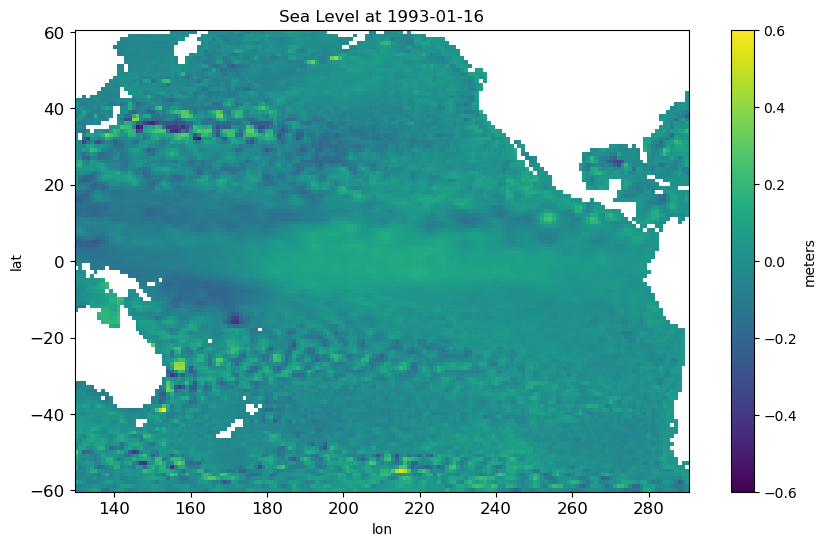

In [ ]:
spatial_slice = ds.sl.isel(time=0)
plt.figure(figsize=(10,6))
# handle the colorbar and axis labels using cbar_kwargs
spatial_slice.plot(cmap='viridis',  cbar_kwargs={'label': 'meters'})

plt.title(f"Sea Level at {spatial_slice.time.dt.strftime('%Y-%m-%d').values}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.axis('scaled') # ensures x and y are similar sized
# ensures y-axis direction is normal (upwards) and set font size
plt.gca().tick_params(labelsize=12)

plt.show()

### Plot: Spatial map of seal level during peak of 2015-2016 El Nino (December 2015)

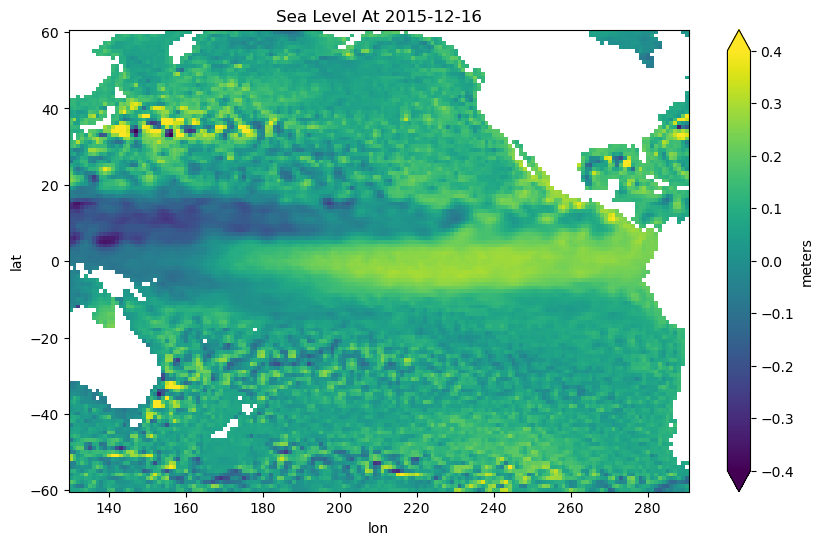

In [73]:
spatial_elnino = ds.sl.sel(time='12-15-2015', method='nearest')

plt.figure(figsize=(10,6))
# vmin/vmax sets the colorbar min and max, respectively
spatial_elnino.plot(cmap='viridis', vmin=-0.4, vmax=0.4, cbar_kwargs={'label': 'meters'})
plt.title(f'Sea Level At {spatial_elnino.time.dt.strftime('%Y-%m-%d').values}')
plt.show()

### Plot: Spatial map of sea level using pcolormesh

Xarray's .plot() defaults to pcolormesh for 2D data. But for consistency with the MATLAB demo, will add a cell code to manually show pcolormesh (pcolor in MATLAB)

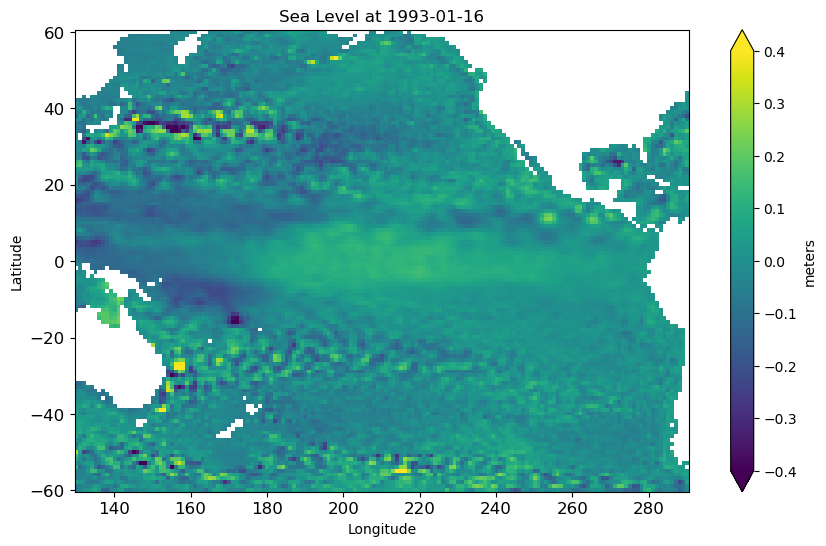

In [ ]:
spatial_slice = ds.sl.isel(time=0)
plt.figure(figsize=(10,6))
spatial_slice.plot.pcolormesh(cmap='viridis',  vmin=-0.4, vmax=0.4, cbar_kwargs={'label': 'meters'})

plt.title(f"Sea Level at {spatial_slice.time.dt.strftime('%Y-%m-%d').values}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.axis('scaled') # ensures x and y are similar sized
plt.show()

### Plot: Spatial map using filled contours (contourf)

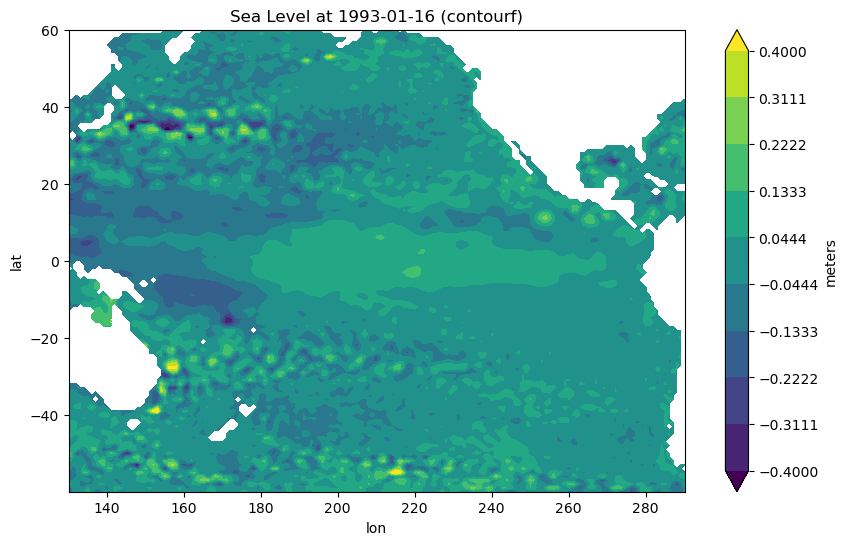

In [90]:
spatial_slice = ds.sl.isel(time=0)

plt.figure(figsize=(10,6))

# levels adjust the resolution of the contours
spatial_slice.plot.contourf(
    levels=10,
    vmin=-0.4, 
    vmax=0.4, 
    cmap='viridis',
    cbar_kwargs={'label':'meters'}
)

plt.title(f"Sea Level at {spatial_slice.time.dt.strftime('%Y-%m-%d').values} (contourf)")

plt.axis('scaled') # ensures x and y are similar sized
plt.show()


### Plot: Spatial map of sea level back to pcolormesh, different color map

[Color Map Documentation](https://matplotlib.org/stable/gallery/color/colormap_reference.html)


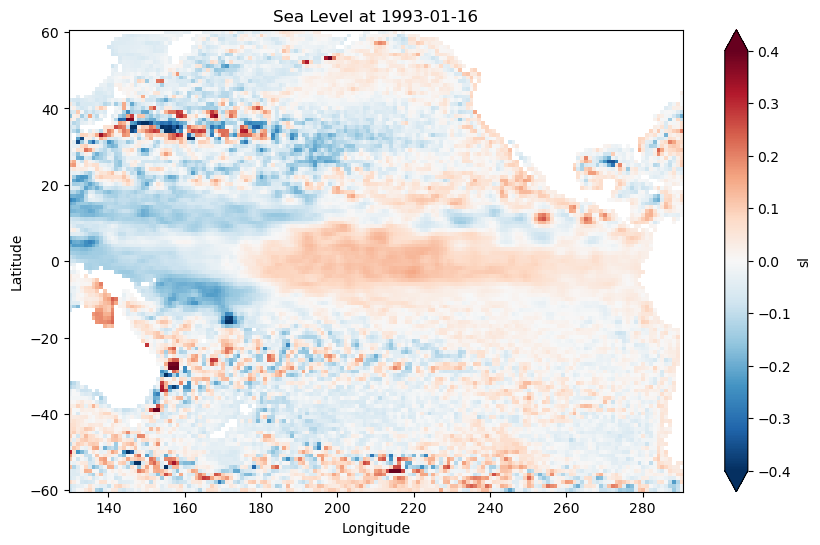

In [94]:
plt.figure(figsize=(10,6))

spatial_slice.plot(cmap='RdBu_r', vmin=-0.4, vmax=0.4)

plt.title(f"Sea Level at {spatial_slice.time.dt.strftime('%Y-%m-%d').values}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.axis('scaled') # ensures x and y are similar sized
plt.show()

### create a movie of sea level

In [99]:
# libraries needed for movie
from Ipython import display 
import time

plt.figure(figsize=(10,6))


ds.time[:20]#

ModuleNotFoundError: No module named 'Ipython'

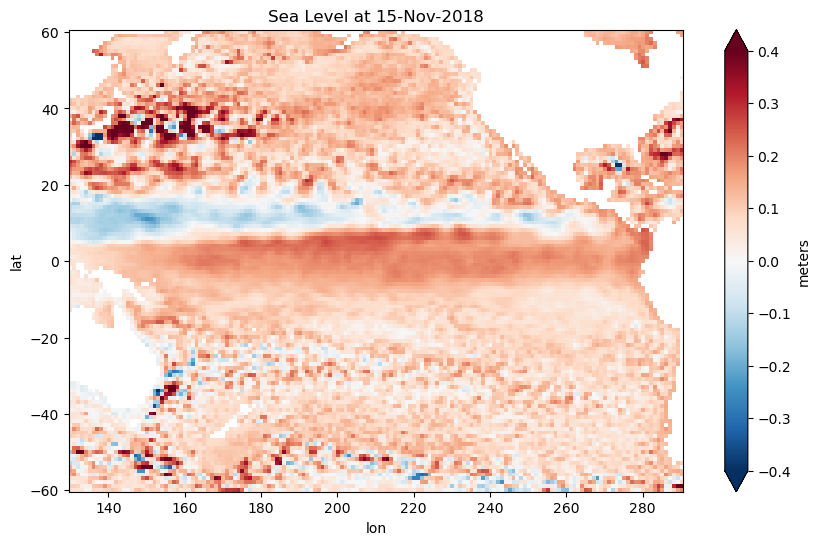

In [96]:
from IPython import display
import matplotlib.pyplot as plt
import time

plt.figure(figsize=(10, 6))

# 2. Loop through time steps (nt)
# We can use a slice like [:20] to test a short version first
for j in range(len(ds.time)):
    plt.clf()  # Equivalent to MATLAB 'clf'
    
    # Plot the current time step
    ds.sl.isel(time=j).plot(
        vmin=-0.4, vmax=0.4, 
        cmap='RdBu_r', 
        cbar_kwargs={'label': 'meters'}
    )
    
    # Formatting
    date_str = ds.time.isel(time=j).dt.strftime('%d-%b-%Y').values
    plt.title(f"Sea Level at {date_str}")
    plt.axis('scaled')
    
    # 3. The "Animation" Magic
    display.display(plt.gcf())    # Show the current figure
    display.clear_output(wait=True) # Clear it for the next one
    time.sleep(0.1)                # Equivalent to MATLAB 'pause(0.1)'